# Assignment 10.2 - Vision Model



## Task 10.2.1: Pre-trained VGG-11 for Image Classification

First, we recommend using PyTorch for this assignment, a popular machine learning framework. Should be able to install it according to the official instructions on [pytorch.org](https://pytorch.org/).

It might be useful to use [Google Colab](https://colab.research.google.com), too. Google offers some compute, so you are not stuck running your programs locally. You can even use GPUs and TPUs! For this assignment, your local machine should be enough, though. In Google Colab variables might get lost when your computer disconnects from the internet or the notebook runs idle for a while.

Browse through the [pytorch tutorials ](https://pytorch.org/tutorials/), they often come as colab notebooks - go and execute some!

* Initialize and import the VGG-11 model using PyTorch. Use it for classifying at least 20 CIFAR10 Images, without training it from scratch. **(RESULT)**

Training for 1 epoch or a few iterations is totally fine, especially if you run it on cpu. Speed depends on your hardware. You can use Google Colab if you don't have a GPU available, to have a bit more compute.

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Load VGG11 with batch normalization (recommended)
# Use weights=models.VGG11_BN_Weights.IMAGENET1K_V1 for the latest PyTorch versions
vgg11 = models.vgg11_bn(pretrained=True)

# CIFAR-10 has 10 classes, but VGG was trained on ImageNet (1000 classes)
# Replace the final classifier layer
num_classes = 10

# Access the last layer of the classifier and replace it
# VGG11 classifier is a Sequential block; index 6 is the final Linear layer
in_features = vgg11.classifier[6].in_features
vgg11.classifier[6] = nn.Linear(in_features, num_classes)

# Move model to device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
vgg11 = vgg11.to(device)

print(f"Model initialized and final layer replaced for {num_classes} classes.")

/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg11_bn-6002323d.pth" to /Users/emeyrose/.cache/torch/hub/checkpoints/vgg11_bn-6002323d.pth


100%|████████████████████████████████████████████████████████████████████████████████| 507M/507M [00:07<00:00, 67.3MB/s]


Model initialized and final layer replaced for 10 classes.


In [ ]:
# CIFAR-10 images are 32x32, but VGG-11 expects 224x224 (ImageNet size)
# We apply Resize and standard Normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Load datasets
train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transform)

# Using small batch size for CPU/local memory efficiency
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=20, shuffle=False)

# Quick Fine-tuning (Training for a few iterations as requested)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(vgg11.parameters(), lr=0.001, momentum=0.9)

vgg11.train()
print("Starting short fine-tuning (100 iterations)...")

for i, (inputs, labels) in enumerate(train_loader):
    if i >= 100: # Limit iterations for speed
        break
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = vgg11(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    if i % 20 == 0:
        print(f"Iteration {i}/100 - Loss: {loss.item():.4f}")

print("Fine-tuning complete.")

Starting short fine-tuning (100 iterations)...
Iteration 0/100 - Loss: 2.2654
Iteration 20/100 - Loss: 1.9935
Iteration 40/100 - Loss: 1.4983
Iteration 60/100 - Loss: 0.9393
Iteration 80/100 - Loss: 0.6357
Fine-tuning complete.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.027966172..1.0607262].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09381345..0.994139].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08064395..1.0385303].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.067474544..0.88349307].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09381345..0.8654038].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09381345..1.0474088].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-

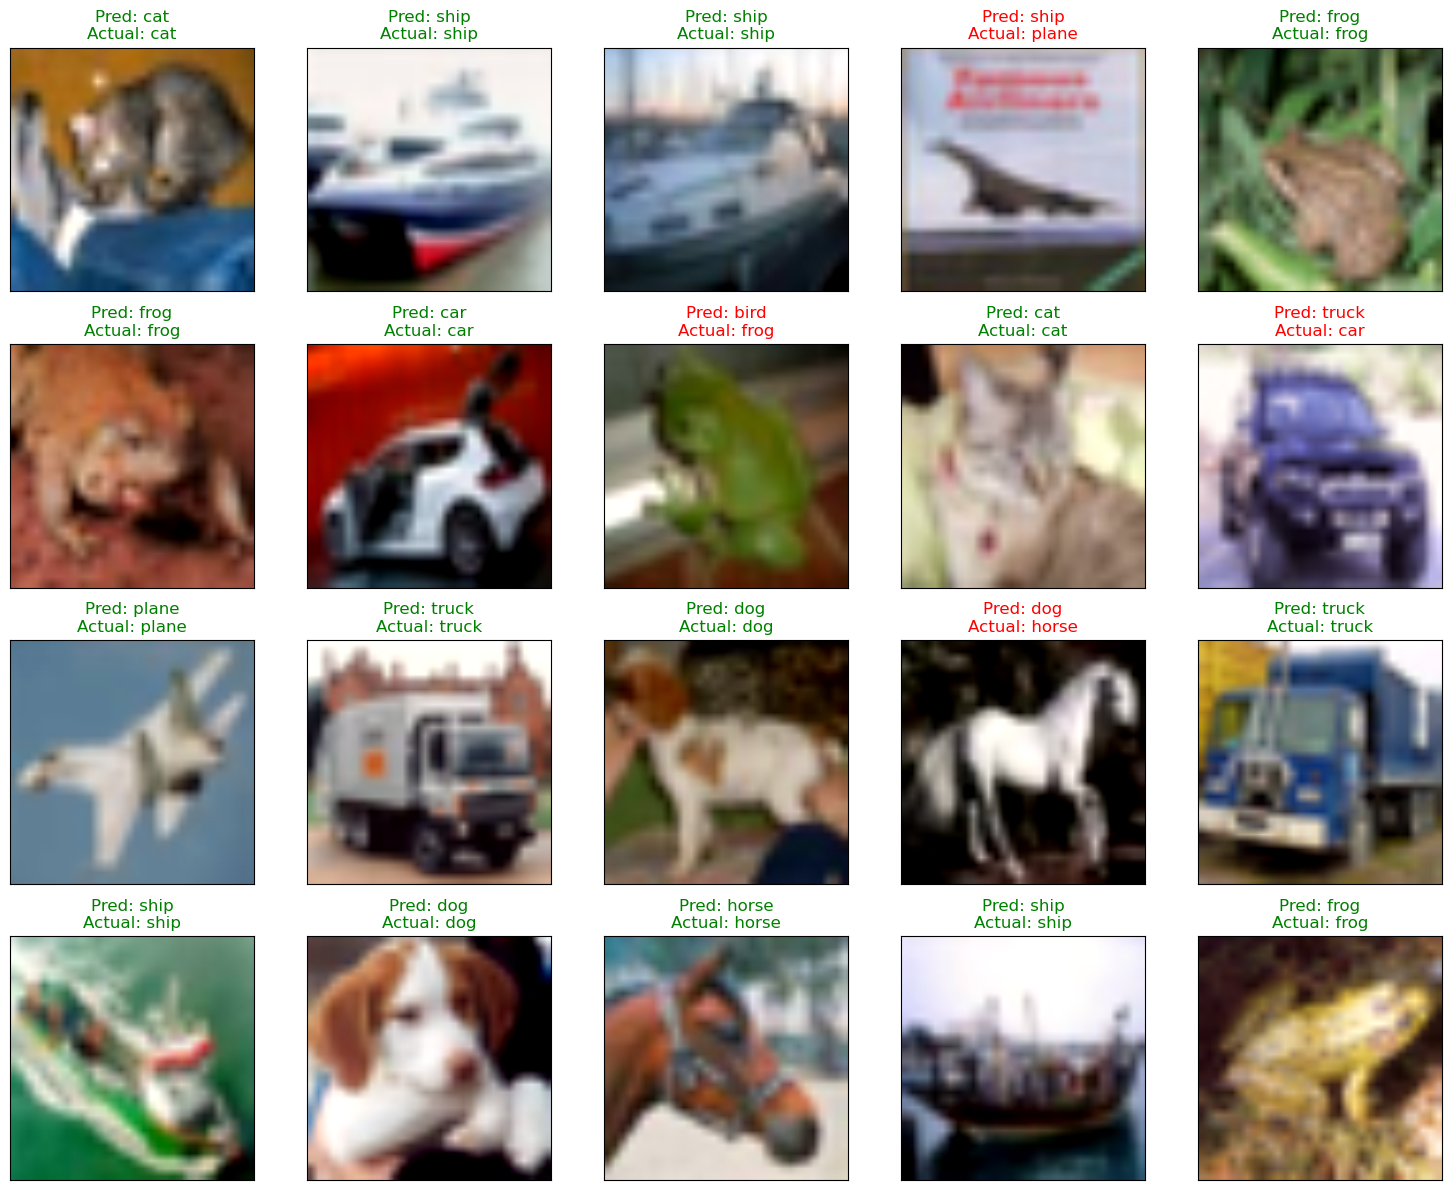

Accuracy on these 20 images: 80.0%


In [ ]:
# Classify 20 images from the test set
vgg11.eval()
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

dataiter = iter(test_loader)
images, labels = next(dataiter) # Get a batch of 20 images
images, labels = images.to(device), labels.to(device)

# Get predictions
outputs = vgg11(images)
_, predicted = torch.max(outputs, 1)

# Function to unnormalize and show image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

# Plot the 20 images with their predicted and actual labels
fig = plt.figure(figsize=(15, 12))
for idx in range(20):
    ax = fig.add_subplot(4, 5, idx+1, xticks=[], yticks=[])
    # Move image to CPU and unnormalize for plotting
    img_plot = images[idx].cpu()
    # Basic unnormalization for visualization
    for t, m, s in zip(img_plot, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]):
        t.mul_(s).add_(m)

    plt.imshow(np.transpose(img_plot.numpy(), (1, 2, 0)))
    color = "green" if predicted[idx] == labels[idx] else "red"
    ax.set_title(f"Pred: {classes[predicted[idx]]}\nActual: {classes[labels[idx]]}", color=color)

plt.tight_layout()
plt.show()

# Calculate accuracy for these 20 images
correct = (predicted == labels).sum().item()
print(f"Accuracy on these 20 images: {100 * correct / 20}%")

## Task 10.2.2: UNet

Now, we want to train another Vision model from scratch again. Moving towards another Vision Task: Image Segmentation.

* Implement a super small UNet using convolutional layers. Your model should be around the parameter count 1-2 million. **(RESULT)**
* Make sure to use Skip Connections. **(RESULT)**
* Train your model on the [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) for image segmentation. **(RESULT)**
* Display some segmentation results on test images. **(RESULT)**

Feel free to use a subset of the dataset, if you are restricted with memory and/or compute. You will find it in ```./data/pet/```.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt
import numpy as np
import os

class SmallUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(SmallUNet, self).__init__()

        def double_conv(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        # Encoder
        self.enc1 = double_conv(in_channels, 32)
        self.enc2 = double_conv(32, 64)
        self.enc3 = double_conv(64, 128)
        self.enc4 = double_conv(128, 256)
        self.pool = nn.MaxPool2d(2)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = double_conv(256, 128) # 128 skip + 128 up
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = double_conv(128, 64) # 64 skip + 64 up
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = double_conv(64, 32) # 32 skip + 32 up

        self.final_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        p1 = self.pool(s1)
        s2 = self.enc2(p1)
        p2 = self.pool(s2)
        s3 = self.enc3(p2)
        p3 = self.pool(s3)
        b1 = self.enc4(p3)

        # Decoder with Skip Connections (torch.cat)
        d3 = self.up3(b1)
        d3 = torch.cat([d3, s3], dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, s2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, s1], dim=1)
        d1 = self.dec1(d1)
        return self.final_conv(d1)

model = SmallUNet()
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}")

Total Parameters: 1,928,417


In [ ]:
class PetsNPZDataset(Dataset):
    """Custom Dataset to load from saved NPZ files"""
    def __init__(self, npz_path, transform=None, target_transform=None):
        self.data = np.load(npz_path)
        self.images = self.data['images']
        self.masks = self.data['masks']
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]
        if self.transform:
            image = torch.from_numpy(image).float() / 255.0
            image = image.permute(2, 0, 1)  # (H, W, C) -> (C, H, W)
        if self.target_transform:
            mask = torch.from_numpy(mask).unsqueeze(0).float()
            mask = (mask == 1.0).float() # Binary mask logic
        return image, mask

# Path setup
train_path = './data/pet/pets_train_20percent.npz'
test_path = './data/pet/pets_test_20percent.npz'


if not os.path.exists(train_path):
    print("Files missing. Downloading official data...")
    os.makedirs('./data/pet/', exist_ok=True)

    raw_train = OxfordIIITPet(root='./data', target_types='segmentation', download=True, split='trainval')

    train_dataset = OxfordIIITPet(root='./data', target_types='segmentation', split='trainval',
                                 transform=transforms.Compose([transforms.Resize((128,128)), transforms.ToTensor()]),
                                 target_transform=transforms.Compose([transforms.Resize((128,128)), transforms.ToTensor()]))
    test_dataset = OxfordIIITPet(root='./data', target_types='segmentation', split='test',
                                transform=transforms.Compose([transforms.Resize((128,128)), transforms.ToTensor()]),
                                target_transform=transforms.Compose([transforms.Resize((128,128)), transforms.ToTensor()]))
else:
    # Use the example logic exactly as provided
    train_dataset = PetsNPZDataset(train_path, transform=True, target_transform=True)
    test_dataset = PetsNPZDataset(test_path, transform=True, target_transform=True)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
print(f"Dataset loaded: {len(train_dataset)} train, {len(test_dataset)} test samples")

Files missing. Downloading official data...
Dataset loaded: 3680 train, 3669 test samples


Training...
Epoch 1 done.
Epoch 2 done.
Epoch 3 done.


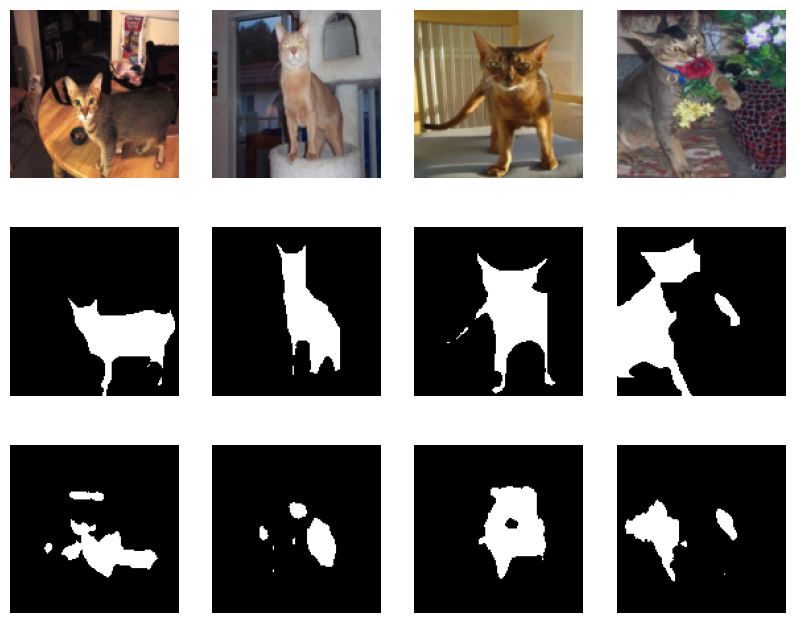

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SmallUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

print("Training...")
model.train()
for epoch in range(3):
    for images, masks in train_loader:
        # If using official dataset, convert trimap to binary
        if not os.path.exists(train_path):
            masks = (masks * 255 == 1.0).float()

        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} done.")

# Plot results
model.eval()
images, masks = next(iter(test_loader))
if not os.path.exists(train_path): masks = (masks * 255 == 1.0).float()

with torch.no_grad():
    preds = torch.sigmoid(model(images.to(device)))
    preds = (preds > 0.5).float()

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for i in range(4):
    axes[0, i].imshow(images[i].permute(1, 2, 0))
    axes[1, i].imshow(masks[i].squeeze(), cmap='gray')
    axes[2, i].imshow(preds[i].cpu().squeeze(), cmap='gray')
    for ax in axes[:, i]: ax.axis('off')
plt.show()